# Exercício sobre transfer learning e ajuste fino de um modelo

Nesse exercício, você irá criar um modelo que detecte se uma foto foi tirada em uma área urbana ou rural. Você poderia construir um novo modelo do zero para esse propósito específico, mas para obter bons resultados, você precisaria de milhares de fotos com rótulos de quais são urbanas e quais são rurais.

Você usará *transfer learning* para treinar um modelo pré-treinado com muito menos dados.

ImageNet é um grande conjunto de dados de imagens, composto por mais de 14 milhões de imagens de milhares de categorias. Keras disponibiliza vários modelos que foram pré-treinados neste conjunto de dados aqui. Um dos modelos é o ResNet.

Você irá adaptar o modelo ResNet50 pré-treinado na base de dados *imagenet* para uma nova tarefa de prever se uma imagem é de uma área rural ou urbana.

Para mais informações sobre o modelo, acesse o link para a documentação da classe: [ResNet50](https://keras.io/api/applications/resnet/#resnet50-function)

**OBS**.: Use o exemplo [transfer_learning.ipynb](https://colab.research.google.com/github/zz4fap/tp557-iot-ml/blob/master/examples/transfer_learning.ipynb) como base para resolver este exercício.

## Importando as bibliotecas

Execute a célula de código abaixo.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

## Pré-processamento dos dados

### Baixe a base de dados

**OBS**.: Como o conjunto de dados é bastante reduzido, usaremos apenas os conjuntos de treinamento e validação. O conjunto de treinamento possui 72 imagens e o de validação apenas 20.

Execute a célula de código abaixo.

In [4]:
_URL = 'https://dl.dropboxusercontent.com/scl/fi/xfrxie8y8xhie2t9ziz27/rural_urban_dataset.zip?rlkey=c1x7i6pk4q86imm4mcstqn5yk&dl=1'

path_to_zip = tf.keras.utils.get_file('rural_urban_dataset.zip', origin=_URL, extract=True)

PATH = os.path.join(os.path.dirname(path_to_zip), 'rural_urban_dataset_extracted', 'rural_and_urban_photos')

# Tenta achar a pasta extraida
if not os.path.exists(PATH):
    PATH = os.path.join(os.path.dirname(path_to_zip), 'rural_and_urban_photos')
print(PATH)

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'val')

# Mini-batch size.
BATCH_SIZE = 10

# Image size.
IMG_SIZE = (224, 224)

train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                            shuffle=True,
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE)

C:\Users\eduar\.keras\datasets\rural_urban_dataset_extracted\rural_and_urban_photos
Found 72 files belonging to 2 classes.


Execute a célula de código abaixo.

In [5]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(validation_dir,
                                                                 shuffle=True,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE)

Found 20 files belonging to 2 classes.


Exibindo as primeiras nove imagens e rótulos do conjunto de treinamento.

Execute a célula de código abaixo.

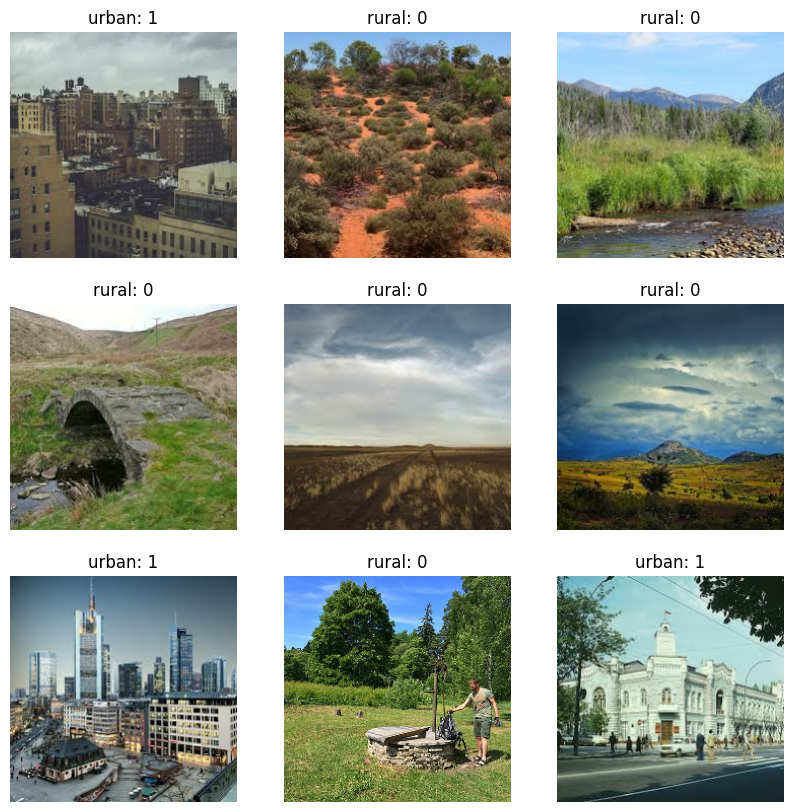

In [6]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]]+': '+str(int(labels[i])))
    plt.axis("off")

### Configurando o conjunto de dados para desempenho

Use a pré-busca (i.e., *prefetch*) em buffer para carregar imagens do disco sem bloquear a E/S.

Execute a célula de código abaixo.

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

### Use data augmentation

Aplique transformações aleatórias às imagens de treinamento.

In [8]:
# Cria as camadas de aumento de dados
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
])

Aplique essas camadas de transformações repetidamente em uma mesma imagem e exiba o resultado.

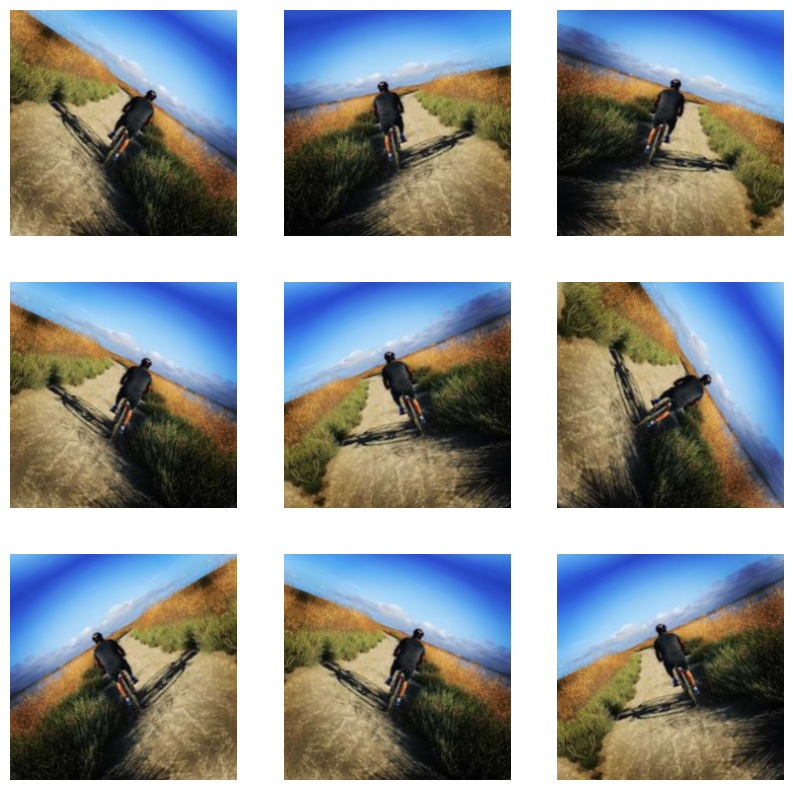

In [9]:
# Pega uma imagem do conjunto de treino
for images, labels in train_dataset.take(1):
    first_image = images[0]

    plt.figure(figsize=(10, 10))

    # Mostra a mesma imagem com varias transformacoes
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0), training=True)
        plt.imshow(augmented_image[0].numpy().astype('uint8'))
        plt.axis('off')

### Redimensione os valores de pixel

Use a função `tf.keras.applications.resnet.preprocess_input` para converter as imagens de entrada de RGB para BGR e, em seguida, centralizar cada canal de cores em relação ao conjunto de dados ImageNet, sem dimensionamento.

Para mais informações sobre o modelo, acesse o link para a documentação da classe: [ResNet50](https://keras.io/api/applications/resnet/#resnet50-function)

In [10]:
# Funcao de pre-processamento usada pela ResNet50
preprocess_input = tf.keras.applications.resnet.preprocess_input

## Crie o modelo base a partir das convnets pré-treinadas

Instancie o modelo ResNet50 com `include_top=False` e `weights='imagenet'`. Lembre-se que o `input_shape` deve ter 3 dimensões.

In [11]:
# Define o formato das imagens de entrada
IMG_SHAPE = IMG_SIZE + (3,)

# Carrega a ResNet50 pre-treinada na ImageNet
base_model = tf.keras.applications.ResNet50(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

# Testa a saida do modelo base com um lote de imagens
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(preprocess_input(image_batch))
print(feature_batch.shape)

(10, 7, 7, 2048)


## Extração de características

Nesta etapa, você deve congelar a base convolucional do modelo criado na etapa anterior e usá-la como extrator de características. Além disso, você deve adicionar um classificador sobre ele e treiná-lo.

### Congele a base convolucional


In [12]:
# Congela os pesos da ResNet50
base_model.trainable = False

### Imprima o resumo do modelo e compare a quantidade de parâmetros treináveis e não treináveis.

In [13]:
# Mostra a estrutura do modelo base
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

### Adicione uma camada de classificação

Gere predições a partir do bloco de características tomando a média das localizações espaciais usando uma camada `tf.keras.layers.GlobalAveragePooling2D` para converter as características em um vetor.

In [14]:
# Cria a camada que transforma mapas de caracteristicas em vetor
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)

print(feature_batch_average.shape)

(10, 2048)


Na sequência, crie uma camada `tf.keras.layers.Dense` para converter essas características em uma única predição por imagem. Não precisamos de uma função de ativação aqui porque esta predição será tratada como um `logit`, ou seja, um valor bruto de predição. Os números positivos predizem a classe 1, os números negativos predizem a classe 0.

In [15]:
# Cria a camada final de classificacao binaria
prediction_layer = tf.keras.layers.Dense(1)
prediction_batch = prediction_layer(feature_batch_average)

print(prediction_batch.shape)

(10, 1)


Crie o modelo encadeando as camadas de aumento de dados, pré-processamento, modelo base (ResNet50), `global_average_layer` e classificador. Adicione uma camada de `dropout` entre a camada `global_average_layer` e a camada de classificação.

Não se esqueça de fazer `training=False` no modelo base (ResNet50), pois o modelo contém camadas de `BatchNormalization`.

In [16]:
# Entrada do modelo
inputs = tf.keras.Input(shape=IMG_SHAPE)

# Aplica aumento de dados e pre-processamento
x = data_augmentation(inputs)
x = preprocess_input(x)

# Usa a ResNet50 como extratora de caracteristicas
x = base_model(x, training=False)
x = global_average_layer(x)

# Reduz sobreajuste antes da classificacao
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)

# Monta o modelo completo
model = tf.keras.Model(inputs, outputs)

### Imprima o resumo do modelo e compare a quantidade de parâmetros treináveis e não treináveis.

In [17]:
# Mostra a estrutura do modelo completo
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Compile o modelo

Compile o modelo antes de treiná-lo. Como existem duas classes, use a perda `tf.keras.losses.BinaryCrossentropy` com `from_logits=True`, pois o modelo fornece uma saída linear (i.e., última camada não tem função de ativação).

**OBS**.: Use um passo de aprendizagem de `0.0001`

In [18]:
# Define a taxa de aprendizado inicial
base_learning_rate = 0.0001

# Compila o modelo para classificacao binaria
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0, name='accuracy')]
)

### Treine o modelo

Verifique a acurácia do modelo sem nenhum treinamento no conjunto de validação.

In [19]:
# Avalia o modelo antes do treinamento
initial_loss, initial_accuracy = model.evaluate(validation_dataset)

print('Initial loss:', initial_loss)
print('Initial accuracy:', initial_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 496ms/step - accuracy: 0.7667 - loss: 0.5903
Initial loss: 0.5411440134048462
Initial accuracy: 0.800000011920929


Treine o modelo por 25 épocas. Você deve ver uma acurácia de aproximadamente 90% no conjunto de validação.

In [20]:
# Treina apenas o classificador por 25 epocas
initial_epochs = 25

history = model.fit(
    train_dataset,
    epochs=initial_epochs,
    validation_data=validation_dataset
)

Epoch 1/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 620ms/step - accuracy: 0.5460 - loss: 0.7666 - val_accuracy: 0.8500 - val_loss: 0.5091
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 594ms/step - accuracy: 0.6026 - loss: 0.6945 - val_accuracy: 0.9500 - val_loss: 0.4859
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 567ms/step - accuracy: 0.6288 - loss: 0.7051 - val_accuracy: 0.9500 - val_loss: 0.4631
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 557ms/step - accuracy: 0.6194 - loss: 0.6417 - val_accuracy: 0.9500 - val_loss: 0.4443
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 565ms/step - accuracy: 0.8295 - loss: 0.4766 - val_accuracy: 0.9500 - val_loss: 0.4271
Epoch 6/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 570ms/step - accuracy: 0.7570 - loss: 0.5601 - val_accuracy: 0.9500 - val_loss: 0.4096
Epoch 7/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 547ms/step - accuracy: 0.7681 - loss: 0.5021 - val_accuracy: 0.9500 - val_loss: 0.3947
Epoch 8/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 551ms/step - accuracy: 0.7254 - loss: 0.4881 - val_accuracy: 0.9500 - val_loss

### Plote as curvas de aprendizado

Analise as curvas de aprendizado da acurácia/perda de treinamento e validação ao usar o modelo base ResNet50 como um extrator de características.

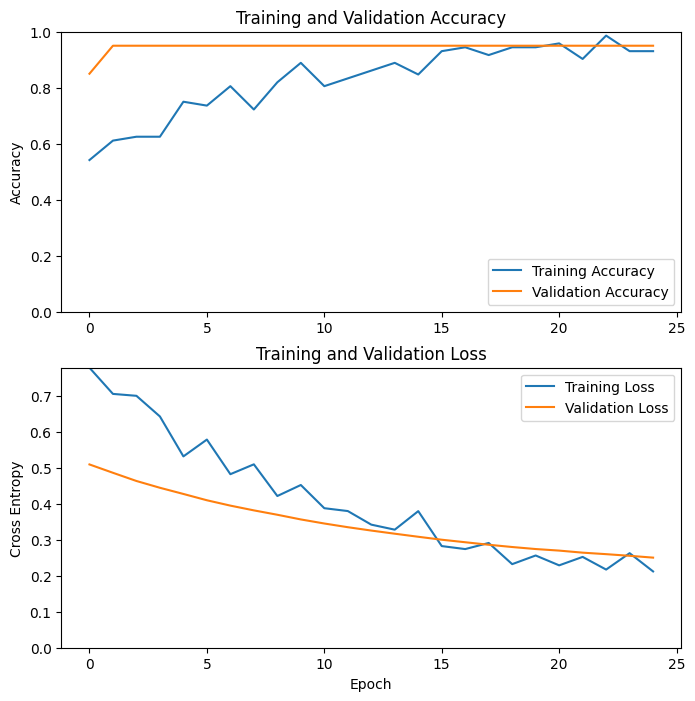

In [21]:
# Guarda os valores de acuracia e erro
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))

# Plota a acuracia
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.title('Training and Validation Accuracy')

# Plota o erro
plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0, max(max(loss), max(val_loss))])
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.show()

## Faça o ajuste fino do modelo


### Descongele as camadas superiores do modelo

Tudo o que você precisa fazer é descongelar o modelo base e definir as camadas inferiores como não treináveis. Em seguida, você deve recompilar o modelo (necessário para que essas alterações tenham efeito) e retomar o treinamento.

### Descongele o modelo base.

In [22]:
# Descongela o modelo base para ajuste fino
base_model.trainable = True

### Congele apenas as 100 primeiras camadas do modelo base.

In [23]:
# Mostra a quantidade de camadas da ResNet50
print('Numero de camadas do modelo base:', len(base_model.layers))

# Mantem as 100 primeiras camadas congeladas
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

Numero de camadas do modelo base: 175


### Compile o modelo

Como você está treinando um modelo muito maior e deseja reajustar os pesos pré-treinados, é importante utilizar uma taxa de aprendizado menor nesta fase. Caso contrário, o modelo poderá se ajustar muito rapidamente.

**OBS**.: Use um passo de aprendizagem 10 vezes menor do que o usado anteriormente.

In [24]:
# Usa uma taxa de aprendizado menor para o ajuste fino
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate / 10),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0, name='accuracy')]
)

### Imprima o resumo do modelo e compare a quantidade de parâmetros treináveis e não treináveis.

In [25]:
# Mostra a estrutura depois do descongelamento parcial
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 19,454,977 (74.21 MB)

 Non-trainable params: 4,134,784 (15.77 MB)

### Continue o treinamento do modelo

Esta etapa deve melhorar a acurácia do modelo em alguns pontos percentuais.

**OBS**.: Faça o ajuste fine do modelo por 15 épocas.

In [26]:
# Continua o treinamento por mais 15 epocas
fine_tune_epochs = 15
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model.fit(
    train_dataset,
    epochs=total_epochs,
    initial_epoch=initial_epochs,
    validation_data=validation_dataset
)

Epoch 26/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8393 - loss: 0.3831 - val_accuracy: 0.9500 - val_loss: 0.2217
Epoch 27/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9838 - loss: 0.1780 - val_accuracy: 0.9500 - val_loss: 0.2086
Epoch 28/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 953ms/step - accuracy: 0.9721 - loss: 0.1705 - val_accuracy: 0.9500 - val_loss: 0.1993
Epoch 29/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 948ms/step - accuracy: 0.9789 - loss: 0.1200 - val_accuracy: 0.9500 - val_loss: 0.1940
Epoch 30/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 927ms/step - accuracy: 0.9882 - loss: 0.1389 - val_accuracy: 0.9500 - val_loss: 0.1888
Epoch 31/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 938ms/step - accuracy: 0.9969 - loss: 0.0876 - val_accuracy: 0.9500 - val_loss: 0.1834
Epoch 32/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 915ms/step - accuracy: 0.9742 - loss: 0.1176 - val_accuracy: 0.9500 - val_loss: 0.1799
Epoch 33/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 935ms/step - accuracy: 1.0000 - loss: 0.0929 - val_accuracy: 0.9500 - val_lo

### Plote as curvas de aprendizado

Analise as curvas de aprendizado da acurácia/perda de treinamento e validação ao usar o modelo base ResNet50 como um extrator de características.

Após o ajuste fino, o modelo deve atingir mais de 98% de acurácia no conjunto de validação.

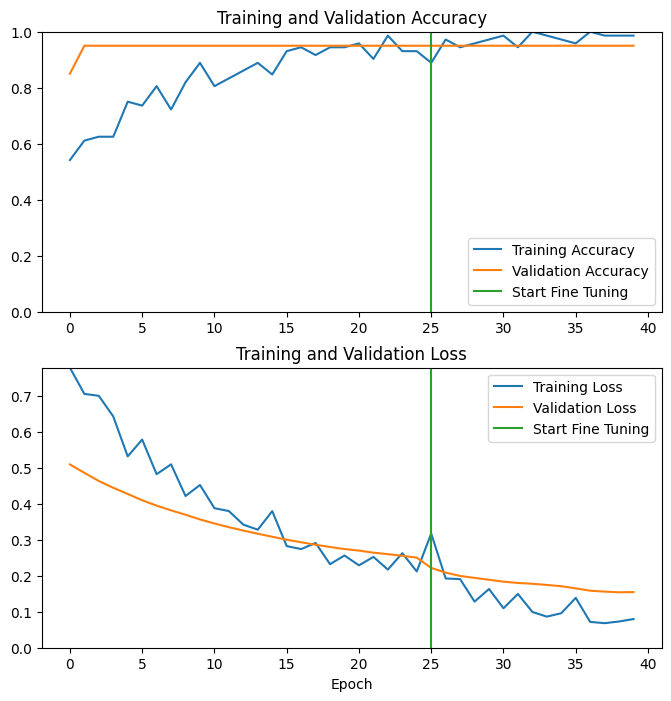

In [27]:
# Junta os resultados das duas etapas
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']
loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

plt.figure(figsize=(8, 8))

# Plota a acuracia depois do ajuste fino
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0, 1])
plt.plot([initial_epochs, initial_epochs], plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plota o erro depois do ajuste fino
plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, max(max(loss), max(val_loss))])
plt.plot([initial_epochs, initial_epochs], plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.show()

### Avalie e faça predições com o modelo

Verifique o desempenho do modelo nos dados do conjunto de validação usando o método `evaluate`.

In [28]:
# Avalia o modelo no conjunto de validacao
loss, accuracy = model.evaluate(validation_dataset)

print('Validation loss:', loss)
print('Validation accuracy:', accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 458ms/step - accuracy: 0.9333 - loss: 0.1847
Validation loss: 0.15460948646068573
Validation accuracy: 0.949999988079071


### Exiba algumas imagens do conjunto de validação juntamente com a classe que foi atribuída a ela.

Predicoes: [0 1 0 0 0 0 0 0 1 1]
Rotulos reais: [0 1 0 0 0 0 0 0 1 1]


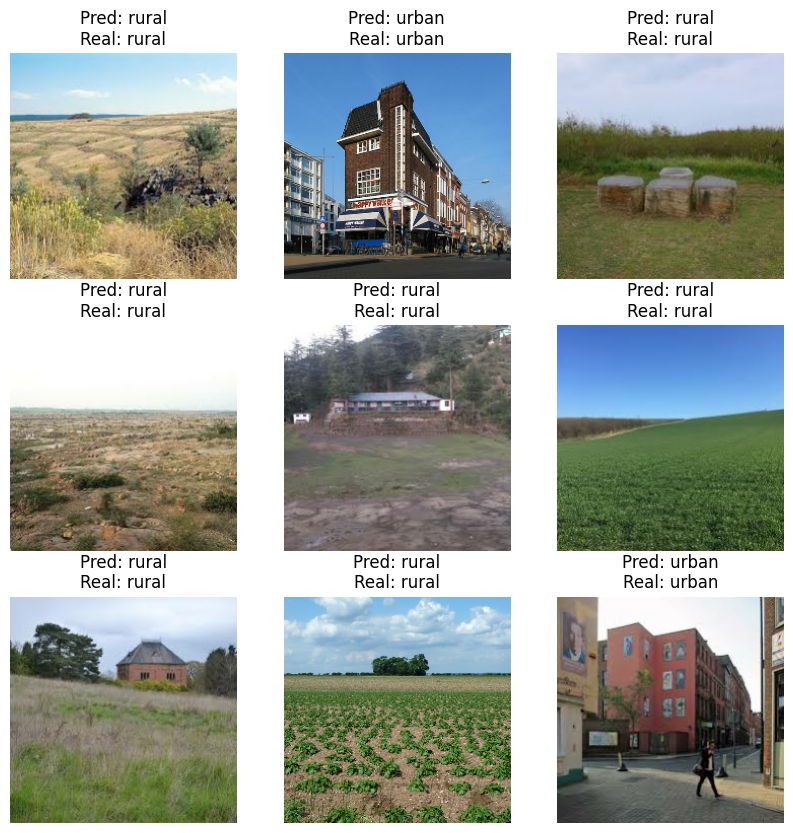

In [29]:
# Pega um lote de imagens de validacao
image_batch, label_batch = next(validation_dataset.as_numpy_iterator())

# Calcula as predicoes do modelo
predictions = model.predict_on_batch(image_batch).flatten()
probabilities = tf.nn.sigmoid(predictions)
predicted_labels = tf.where(probabilities < 0.5, 0, 1).numpy()

print('Predicoes:', predicted_labels)
print('Rotulos reais:', label_batch)

plt.figure(figsize=(10, 10))

# Mostra as imagens com a classe prevista
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].astype('uint8'))
    title = 'Pred: ' + class_names[predicted_labels[i]]
    title = title + '\nReal: ' + class_names[label_batch[i]]
    plt.title(title)
    plt.axis('off')

### Apos analisar os resultados gerados pelo novo modelo, o que voce pode concluir?

**Resposta**

O modelo conseguiu aproveitar os pesos treinados na ImageNet para aprender com poucas imagens. A acuracia de validacao ficou alta depois do ajuste fino, indicando que o transfer learning foi adequado para separar imagens rurais e urbanas. Como a base e pequena, o resultado pode variar e seria melhor testar com mais imagens antes de usar em um caso real.